# 02 - Bias and Fairness Analysis

**NovaCred Credit Application Governance Analysis**

This notebook documents the bias and fairness assessment of the cleaned credit
applications dataset. We systematically evaluate potential disparities in loan
approval outcomes across protected and related attributes, focusing on
**gender bias**, **age-based discrimination**, and **proxy discrimination**.

The analysis includes the computation of **fairness metrics** (such as the
Disparate Impact Ratio), **statistical significance testing**, and exploratory
analysis of **interaction effects** between demographic attributes.
The goal is to identify whether the credit approval process exhibits patterns
that may indicate unfair or discriminatory outcomes.

## 1. Imports & Load Data 

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from dateutil import parser as date_parser


df = pd.read_csv("../data/cleaned_credit_applications.csv")
df.shape, df.columns.tolist()

((500, 29),
 ['app_id',
  'full_name',
  'email',
  'ssn',
  'ip_address',
  'gender',
  'date_of_birth',
  'zip_code',
  'annual_income',
  'credit_history_months',
  'debt_to_income',
  'savings_balance',
  'spending_total',
  'spending_categories',
  'spending_category_list',
  'loan_approved',
  'interest_rate',
  'approved_amount',
  'rejection_reason',
  'processing_timestamp',
  'loan_purpose',
  'notes',
  'gender_original',
  'date_of_birth_original',
  'high_dti_flag',
  'email_valid',
  'completeness_score',
  'completeness_pct',
  'ssn_duplicate_flag'])

## 2. Outcome And Age Variable Calculation

In this section, we prepare key variables required for the bias and fairness analysis. 
Specifically, we construct the binary **loan approval outcome** used throughout the analysis 
and derive an **age variable** from the applicants' date of birth. 

To facilitate fairness assessments, applicants are additionally grouped into **age categories**, 
allowing us to evaluate potential disparities in loan approval outcomes across demographic groups. 
These variables serve as the basis for subsequent fairness metrics, statistical testing, 
and bias analysis.

### 2.1 Define Loan Approval Outcome

In [25]:
# Outcome
df["loan_approved"] = df["loan_approved"].astype(bool)

### 2.2 Compute Applicant Age

In [27]:
# Age from date_of_birth (cleaning notebook already parsed dates at some point, but CSV may store as string)
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")

today = pd.Timestamp("today").normalize()
df["age"] = ((today - df["date_of_birth"]).dt.days / 365.25).round(1)

### 2.3 Create Age Groups

In [29]:
# Age groups (feel free to tweak bins after you look at distribution)
bins = [0, 29, 44, 59, 120]
labels = ["<30", "30–44", "45–59", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

### 2.4 Age Distribution Histogram

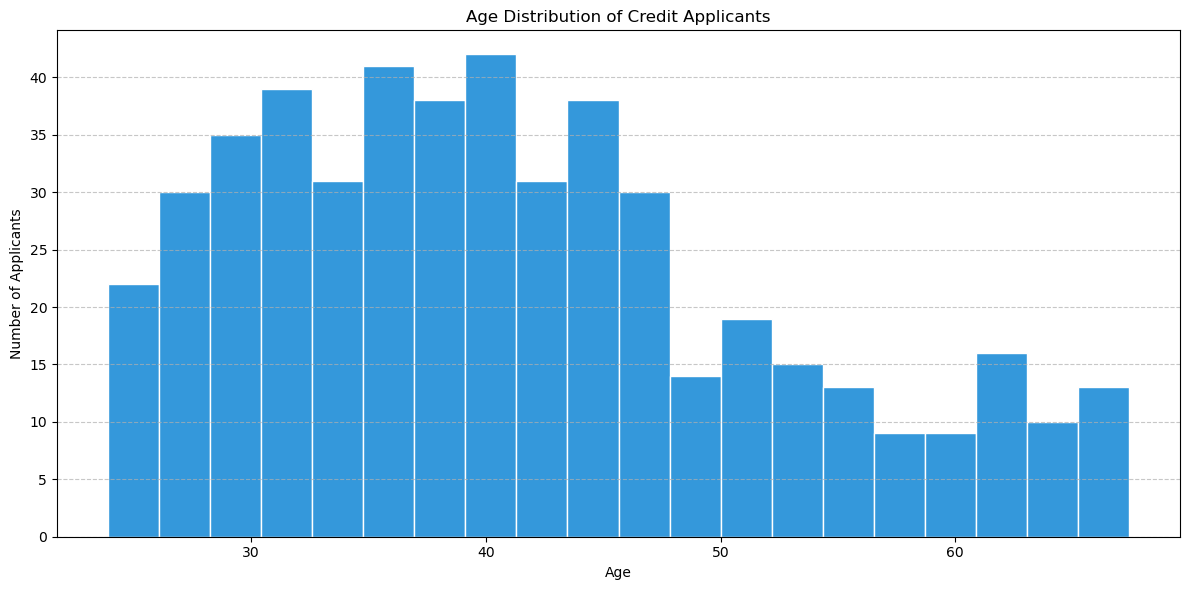

In [23]:
# Age distribution visualization (consistent style with Data Quality notebook)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_main["age"], bins=20, color="#3498db", edgecolor="white")

ax.set_title("Age Distribution of Credit Applicants")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Applicants")

# add gridlines like in the data quality notebook
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 3. Main Cohort Definition

This section defines the primary analysis cohort, which is used to analyze fairness and bias.
To guarantee methodological consistency, we restrict the dataset to applicants with a valid binary gender classification (**Male/Female**) for the baseline Disparate Impact analysis, ensuring non-missing data.**Age** values are for age-based and intersectional analysis.

To ensure transparency and reproducibility, we document cohort size and group numbers after filtering down below.

In [32]:
# Define main cohort used for the bias analysis

total_records = len(df)

# keep only applicants with binary gender (Male / Female)
gender_filter = df["gender"].isin(["Male", "Female"])
records_after_gender_filter = gender_filter.sum()

# ensure age is available for age-related analysis
age_filter = df["age"].notna()
records_after_age_filter = (gender_filter & age_filter).sum()

# create main analysis dataset
df_main = df[gender_filter & age_filter].copy()

# summary of filtering steps
cohort_summary = pd.DataFrame({
    "Step": ["Total records","After gender filter","After gender + age filter (df_main)"],
    "Records": [total_records,int(records_after_gender_filter),int(records_after_age_filter)],
    "Dropped": [0,int(total_records - records_after_gender_filter),int(records_after_gender_filter - records_after_age_filter)]
})

cohort_summary

,Step,Records,Dropped
0,Total records,500,0
1,After gender filter,498,2
2,After gender + age filter (df_main),495,3


## 4. Gender Bias: Disparate Impact + Statistical Test

Here, we examine whether the **loan approval rate** differs between gender groups.
To do this, we do two things:

1) **Disparate Impact (DI) Ratio**: Approval Rate (Female) / Approval Rate (Male) and classification according to the **Four-Fifths Rule (0.8)**
2) **Significance test**: Chi-square test on the 2×2 crosstab (gender × approval), plus **Cramér's V** as effect size

Important: These are **associations**, not causal statements.

### 4.1 Approval rates by gender

In [34]:
approval_by_gender = df_main.groupby("gender")["loan_approved"].mean().sort_index()
counts_by_gender = df_main["gender"].value_counts().sort_index()

approval_by_gender, counts_by_gender

(gender
 Female    0.506024
 Male      0.658537
 Name: loan_approved, dtype: float64,
 gender
 Female    249
 Male      246
 Name: count, dtype: int64)

### 4.2 Disparate Impact

In [35]:
privileged = "Male"
protected = "Female"

di_gender = approval_by_gender[protected] / approval_by_gender[privileged]
di_gender

np.float64(0.7684069611780454)

### 4.3 Four-fifths rule as an interpretation helper

In [36]:
def four_fifths_interpretation(di_value: float, threshold: float = 0.8) -> str:
    if di_value < threshold:
        return f"DI={di_value:.3f} < {threshold}: potential adverse impact under the four-fifths rule."
    return f"DI={di_value:.3f} ≥ {threshold}: no adverse impact flagged by the four-fifths rule."

four_fifths_interpretation(di_gender)

'DI=0.768 < 0.8: potential adverse impact under the four-fifths rule.'

### 4.4 Chi-square test (Gender x Approval) + Cramér's V

In [37]:
ct_gender = pd.crosstab(df_main["gender"], df_main["loan_approved"])
ct_gender

loan_approved,False,True
gender,,
Female,123,126
Male,84,162


In [38]:
chi2, p, dof, expected = stats.chi2_contingency(ct_gender)

# Cramér's V (effect size)
n = ct_gender.to_numpy().sum()
r, k = ct_gender.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, k-1)))

chi2, p, cramers_v

(np.float64(11.211547625416834),
 np.float64(0.0008128989785515719),
 np.float64(0.15049781115504057))

#### The bar chart below visualizes the approval rate difference between the two gender groups:

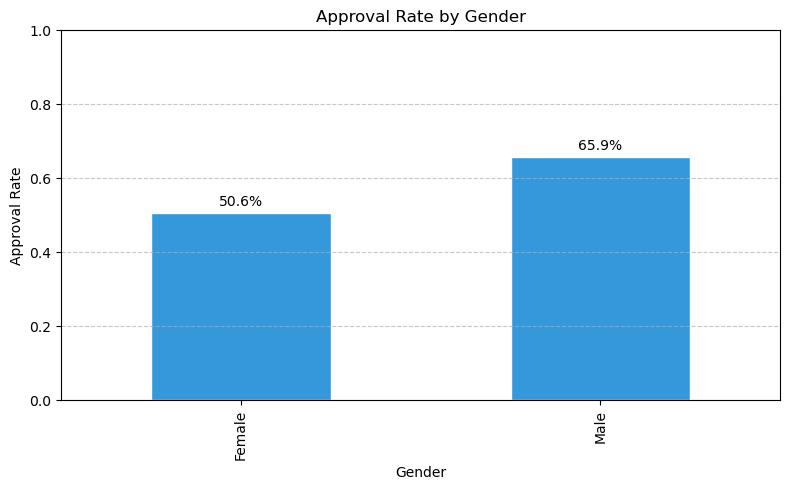

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
approval_by_gender.plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Approval Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in approval_by_gender], padding=3)
plt.tight_layout()
plt.show()

#### Interpretation:

- The acceptance rate varies significantly between gender groups. Female candidates had an approval rate of **50.6%**, whilst male applicants are approved in **65.9%** of situations.

- The resulting **Disparate Impact (DI) ratio is 0.768**, which is **less than the Four-Fifths Rule threshold of 0.8.** According to this rule, the outcome **indicates a potential negative impact on female applicants.**

- The **Chi-Square test** produces a p-value of 0.0008, suggesting that the observed difference in approval rates between genders is **statistically significant** and is unlikely to be explained by random fluctuation.

- However, the **Cramér's V value of 0.15 indicates a modest association** between gender and loan approval. This means that, while the difference is statistically important, the relationship's overall strength is **moderate to small**.

Overall, the analysis demonstrates **a detectable gender gap in approval outcomes**, however the impact size implies that gender alone accounts for only a portion of the variation in loan choices. Importantly, these findings indicate statistical relationships rather than causal discrimination.

### 4.5 Uncertainty: Bootstrap CI for DI (Gender)

DI represents a weighted score. To avoid looking overly harsh, we estimate a **bootstrap confidence interval** by resampling candidates with replacement and recalculating DI each time.


In [43]:
rng = np.random.default_rng(42)

def compute_di_ratio(df_in: pd.DataFrame, protected: str, privileged: str) -> float:
    rates = df_in.groupby("gender")["loan_approved"].mean()
    return float(rates[protected] / rates[privileged])

def bootstrap_di_ci(df_in: pd.DataFrame, protected: str, privileged: str, B: int = 2000, alpha: float = 0.05):
    di_samples = []
    n = len(df_in)
    for _ in range(B):
        idx = rng.integers(0, n, n)
        boot = df_in.iloc[idx]
        # ensure both groups exist in the sample
        if set([protected, privileged]).issubset(set(boot["gender"].unique())):
            di_samples.append(compute_di_ratio(boot, protected, privileged))
    di_samples = np.array(di_samples)
    lo = np.quantile(di_samples, alpha/2)
    hi = np.quantile(di_samples, 1 - alpha/2)
    return float(lo), float(hi), di_samples

di_lo, di_hi, di_samples = bootstrap_di_ci(df_main, protected="Female", privileged="Male")
di_gender, (di_lo, di_hi), len(di_samples)

(np.float64(0.7684069611780454),
 (0.6569183337964248, 0.8911994733108863),
 2000)

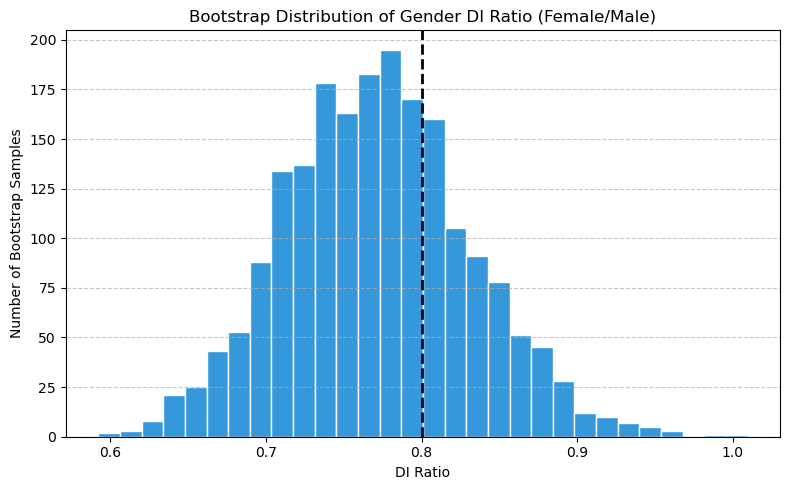

(0.6569183337964248, 0.8911994733108863)

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(di_samples, bins=30, color="#3498db", edgecolor="white")
ax.axvline(0.8, linestyle="--", linewidth=2, color="black")
ax.set_title("Bootstrap Distribution of Gender DI Ratio (Female/Male)")
ax.set_xlabel("DI Ratio")
ax.set_ylabel("Number of Bootstrap Samples")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

(di_lo, di_hi)

#### Interpretation:

- The estimated Disparate Impact is 0.768, meaning that female applicants are approved at about 77% of the approval rate of male applicants. This falls below the four-fifths threshold (0.8) and therefore indicates potential adverse impact against female applicants.

- The bootstrap confidence interval ranges from about 0.66 to 0.89. Since this interval partly crosses the 0.8 threshold, the exact level of disparity varies across samples.

Still, the results suggest a meaningful gender difference in approval rates, although the bootstrap analysis shows that the strength of this effect is somewhat uncertain.

## 5. Age-Based Patterns (Approval Rates + Test)

Here, we investigate whether approval rates differ systematically across **age_groups**.
This is a classic 'age discrimination pattern' signal.

### 5.1 Approval rate by age group

In [46]:
approval_by_age_group = df_main.groupby("age_group", observed=False)["loan_approved"].mean()
counts_by_age_group = df_main["age_group"].value_counts().sort_index()

approval_by_age_group, counts_by_age_group

(age_group
 <30      0.400000
 30–44    0.605578
 45–59    0.614173
 60+      0.638298
 Name: loan_approved, dtype: float64,
 age_group
 <30       70
 30–44    251
 45–59    127
 60+       47
 Name: count, dtype: int64)

### 5.2 Chi-square test (AgeGroup x Approval)

In [47]:
ct_age = pd.crosstab(df_main["age_group"], df_main["loan_approved"])
chi2_age, p_age, dof_age, expected_age = stats.chi2_contingency(ct_age)

# Cramér's V for kx2
n_age = ct_age.to_numpy().sum()
r_age, k_age = ct_age.shape
cramers_v_age = np.sqrt((chi2_age / n_age) / (min(r_age-1, k_age-1)))

chi2_age, p_age, cramers_v_age

(np.float64(11.255878610304752),
 np.float64(0.01041973282633854),
 np.float64(0.15079505531577078))

### 5.3 Visualization of Age-Based Patterns

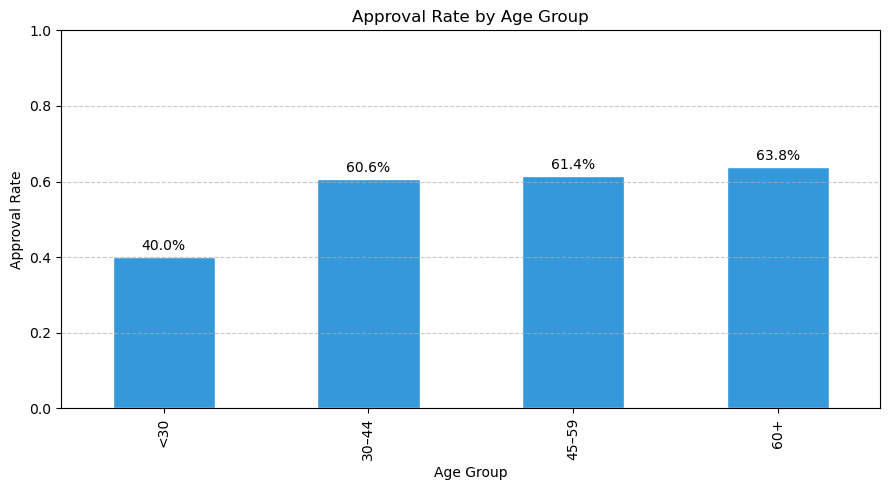

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
approval_by_age_group.loc[["<30","30–44","45–59","60+"]].plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Approval Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in approval_by_age_group.loc[["<30","30–44","45–59","60+"]]], padding=3)
plt.tight_layout()
plt.show()

#### Interpretation:

- Approval rates rise with age, from 40% for under 30 to 64% for over 60 year olds
- The chi-square test is significant with **p ≈ 0.01**, indicating that the differences between age groups are statistically credible and not a coincidence 
- With **Cramér's V ≈ 0.15**, the influence is **small to moderate**: there is a pattern, but age cannot explain 'all'

Overall, this appears to be a **systematic age pattern** (younger candidates have a considerably lower approval rate).

## 6. Interaction Effects (Gender × Age Group)

Examining gender or age individually is often too vague. Here we look at **intersectional patterns**: e.g. whether differences are particularly pronounced in certain age groups.

### 6.1 Intersectional approval table

In [56]:
age_order = ["<30", "30–44", "45–59", "60+"]

gender_age_approval = (df_main.groupby(["age_group", "gender"], observed=False)["loan_approved"].mean().unstack("gender").reindex(age_order))

gender_age_approval

gender,Female,Male
age_group,,
<30,0.315789,0.500000
30–44,0.536585,0.671875
45–59,0.539683,0.687500
60+,0.560000,0.727273


### 6.2 Grouped bar plot

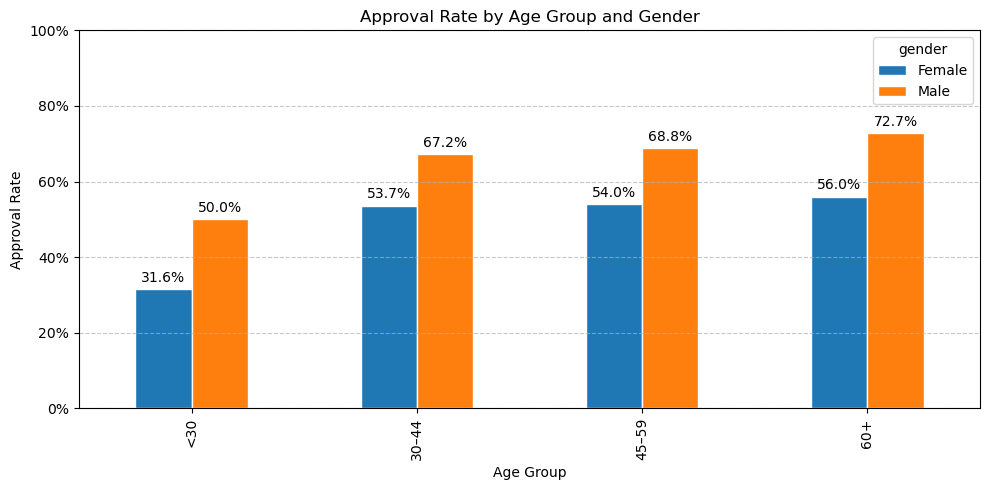

In [70]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10, 5))
gender_age_approval.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Approval Rate by Age Group and Gender")
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers: ax.bar_label(container, labels=[f"{v*100:.1f}%" for v in container.datavalues], padding=3)
plt.tight_layout()
plt.show()

### 6.3 Test: treat (gender, age_group) as categories vs approval

This quick test treats each gender–age combination as a separate group to verify whether approval outcomes differ across these intersectional categories.

In [72]:
ct_inter = pd.crosstab(df_main["age_group"].astype(str) + " | " + df_main["gender"].astype(str),
                       df_main["loan_approved"])
chi2_i, p_i, dof_i, exp_i = stats.chi2_contingency(ct_inter)
chi2_i, p_i

(np.float64(22.59416663555567), np.float64(0.002005202289703433))

#### Interpretation:

- The approval disparity between men and women exists throughout all age groups, with men continually receiving greater approval scores

- The gap is especially obvious among younger candidates, where female approval rates are significantly lower than male approval rates

- Approval rates tend to rise with age for both genders, implying that older applicants are more likely to be approved overall

- The interaction test indicates that approval outcomes vary considerably by gender and age (p = 0.002). This suggests that gender and age are connected with approval outcomes

## 7. Proxy Discrimination Check: zip_code

Proxy discrimination means that a ‘harmless’ feature (e.g. geography) is strongly related to protected attributes
and/or shows highly varying approval outcomes.

We check three things:
1) Which postcodes have sufficient sample size (otherwise it is noise)?
2) Postcode <--> gender (Association, e.g. Cramér's V)
3) Postcode <--> approval (Approval rate differences)

### 7.1 Keep only zips with enough volume (stability)

In [74]:
zip_counts = df_main["zip_code"].value_counts()
top_zips = zip_counts[zip_counts >= 15].index  # threshold can be adjusted
df_zip = df_main[df_main["zip_code"].isin(top_zips)].copy()

len(df_main), len(df_zip), df_zip["zip_code"].nunique()

(495, 0, 0)

### 7.2 zip_code -> approval rate (rank)

In [75]:
zip_approval = df_zip.groupby("zip_code")["loan_approved"].mean().sort_values(ascending=False)
zip_approval.head(10), zip_approval.tail(10)

(Series([], Name: loan_approved, dtype: float64),
 Series([], Name: loan_approved, dtype: float64))

### 7.3 Visual: approval rate by zip (top N)

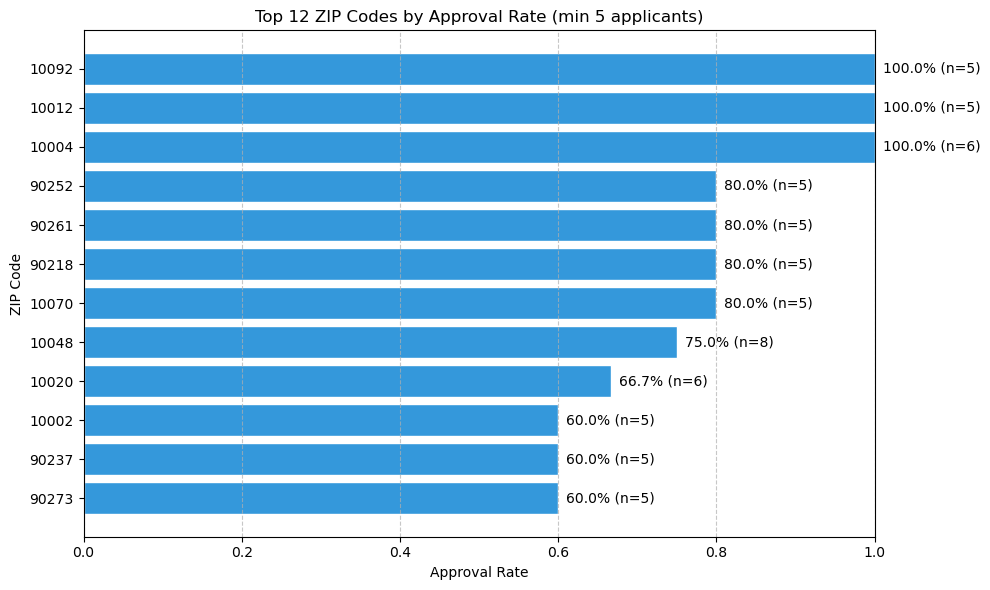

In [83]:
MIN_N = 5   # minimum applicants per ZIP
N = 12      # number of ZIPs to display

zip_stats = (df_main.groupby("zip_code", observed=False)["loan_approved"].agg(approval_rate="mean", n_applicants="size"))

# keep only ZIPs with enough observations
zip_stats = zip_stats[zip_stats["n_applicants"] >= MIN_N]

# take top N and sort for horizontal bars
topN_zip = zip_stats.sort_values("approval_rate", ascending=False).head(N).sort_values("approval_rate")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(topN_zip.index.astype(int).astype(str), topN_zip["approval_rate"], color="#3498db", edgecolor="white")

ax.set_title(f"Top {N} ZIP Codes by Approval Rate (min {MIN_N} applicants)")
ax.set_xlabel("Approval Rate")
ax.set_ylabel("ZIP Code")
ax.set_xlim(0, 1)
ax.grid(axis="x", linestyle="--", alpha=0.7)

# percentage labels
for i, (v, n) in enumerate(zip(topN_zip["approval_rate"], topN_zip["n_applicants"])):
    ax.text(v + 0.01, i, f"{v*100:.1f}% (n={n})", va="center")

plt.tight_layout()
plt.show()

### 7.4 zip_code <--> gender association (Cramér’s V)

In [85]:
MIN_N = 5

# Start from main cohort (already has age + binary gender baseline)
df_zip = df_main.copy()

# ensure only Male/Female for this association test
df_zip = df_zip[df_zip["gender"].isin(["Male", "Female"])].copy()

# filter zipcodes with enough applicants
zip_counts = df_zip["zip_code"].value_counts()
valid_zips = zip_counts[zip_counts >= MIN_N].index
df_zip = df_zip[df_zip["zip_code"].isin(valid_zips)].copy()

if df_zip.empty:
    print(f"After filtering (min {MIN_N} applicants per ZIP), there is no data left for zip_code × gender test.")
else:
    ct_zip_gender = pd.crosstab(df_zip["zip_code"], df_zip["gender"])

    # if table collapses (e.g., only one gender left), chi-square is not defined
    if ct_zip_gender.shape[0] < 2 or ct_zip_gender.shape[1] < 2:
        print("zip_code × gender table has <2 rows or <2 columns after filtering; chi-square/Cramér's V not defined.")
        display(ct_zip_gender)
    else:
        chi2_zg, p_zg, dof_zg, expected_zg = stats.chi2_contingency(ct_zip_gender)

        n = ct_zip_gender.to_numpy().sum()
        r, k = ct_zip_gender.shape
        cramers_v_zg = np.sqrt((chi2_zg / n) / (min(r - 1, k - 1)))

        # outputs
        p_zg, cramers_v_zg, ct_zip_gender.shape

This test checks whether gender distribution differs systematically across ZIP codes, which could indicate that location acts as a proxy for gender-related differences in the dataset.

### 7.5 zip_code <--> age differences

In [86]:
zip_age_summary = df_zip.groupby("zip_code")["age"].agg(["count","mean","std"]).sort_values("count", ascending=False)
zip_age_summary.head(10)

,count,mean,std
zip_code,,,
10048.0,8,39.412500,13.509937
90284.0,7,46.128571,12.485287
10096.0,7,35.457143,5.777502
10004.0,6,43.750000,11.939305
10019.0,6,40.466667,7.689907
10020.0,6,40.983333,7.216209
10057.0,6,43.866667,11.011206
90218.0,5,37.220000,5.200673
90273.0,5,36.720000,9.585249


#### Interpretation:

- Approval rates vary significantly among ZIP codes (approximately 60% to 100% for the top ZIPs), implying that geography may influence loan approval outcomes.

- Most ZIP codes have small sample sizes (n≈5-8), so extreme numbers (e.g., 100%) may be influenced by sampling noise.

- The extra association test determines whether ZIP code is connected to gender distribution, which raises the possibility that geography serves as a proxy for protected characteristics.

Overall, ZIP codes tend to vary in approval outcomes, but given the small group sizes, the results should be regarded with caution rather than as clear proof of discrimination.

## 8. **(Optional)** Fairness Library Cross-Check (fairlearn)

This step checks the previously computed fairness metrics. It applies comparable principles to the Disparate Impact analysis, utilizing the Fairlearn library's terminology and implementations (for example, demographic parity difference and ratio). If the Fairlearn package is not available in the environment, the analysis is gently bypassed with a try/except block to ensure reproducibility.

In [88]:
try:
    from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, demographic_parity_ratio
    FAIRLEARN_AVAILABLE = True
except Exception as e:
    FAIRLEARN_AVAILABLE = False
    fairlearn_error = str(e)

FAIRLEARN_AVAILABLE, (fairlearn_error if not FAIRLEARN_AVAILABLE else "ok")

(False, "No module named 'fairlearn'")

In [89]:
if FAIRLEARN_AVAILABLE:
    y_true = df_main["loan_approved"]  # here: actual approvals (outcome)
    # fairness metrics treat this as "selection" outcome
    mf = MetricFrame(
        metrics={"selection_rate": selection_rate},
        y_true=y_true,
        y_pred=y_true,  # selection_rate uses y_pred; here outcome itself
        sensitive_features=df_main["gender"]
    )
    mf.by_group

In [90]:
if FAIRLEARN_AVAILABLE:
    dp_diff = demographic_parity_difference(y_true=y_true, y_pred=y_true, sensitive_features=df_main["gender"])
    dp_ratio = demographic_parity_ratio(y_true=y_true, y_pred=y_true, sensitive_features=df_main["gender"])
    dp_diff, dp_ratio